In [1]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt # for making figures
%matplotlib inline

In [2]:
words = open('names.txt', 'r').read().splitlines()
print(len(words))
print(max(len(w) for w in words))
print(words[:8])

32033
15
['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia']


In [3]:
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s,i in stoi.items()}
vocab_size = len(itos)
print(itos)
print(vocab_size)

{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}
27


In [4]:
block_size = 3

def build_dataset(words):
  X, Y = [], []

  for w in words:
    context = [0] * block_size
    for ch in w + '.':
      ix = stoi[ch]
      X.append(context)
      Y.append(ix)
      context = context[1:] + [ix]

  X = torch.tensor(X)
  Y = torch.tensor(Y)
  print(X.shape, Y.shape)
  return X, Y

import random
random.seed(42)
random.shuffle(words)
n1 = int(0.8*len(words))
n2 = int(0.9*len(words))

Xtr,  Ytr  = build_dataset(words[:n1])
Xdev, Ydev = build_dataset(words[n1:n2])
Xte,  Yte  = build_dataset(words[n2:])

torch.Size([182625, 3]) torch.Size([182625])
torch.Size([22655, 3]) torch.Size([22655])
torch.Size([22866, 3]) torch.Size([22866])


In [5]:
def cmp(s,dt,t):
    ex=torch.all(dt==t.grad).item()
    app=torch.allclose(dt,t.grad)
    maxdiff=(dt-t.grad).abs().max().item()
    print(f'{s:15s} | exact: {str(ex):5s} | approximate: {str(app):5s} | maxdiff: {maxdiff}')

In [7]:
n_emb=10
n_hidden=64
g=torch.Generator().manual_seed(2147483647)
C=torch.randn((vocab_size,n_emb),generator=g)
W1 = torch.randn((n_emb * block_size, n_hidden), generator=g) * (5/3)/((n_emb * block_size)**0.5)
b1=torch.randn(n_hidden,generator=g)*0.1
W2=torch.randn((n_hidden,vocab_size),generator=g)*0.1
b2 = torch.randn(vocab_size,generator=g) * 0.1
bngain = torch.randn((1, n_hidden))*0.1 + 1.0
bnbias = torch.randn((1, n_hidden))*0.1
parameters=[C,W1,b1,W2,b2,bngain,bnbias]
print(sum(p.nelement() for p in parameters))
for p in parameters: p.requires_grad=True

4137


In [9]:
batch_size = 32
n=batch_size
ix=torch.randint(0,Xtr.shape[0],(batch_size,),generator=g)
Xb, Yb = Xtr[ix], Ytr[ix]

In [10]:
emb=C[Xb]
embcat=emb.view(emb.shape[0],-1)
hprebn=embcat@W1+b1
bnmeani=1/n*hprebn.sum(0,keepdim=True)
bndiff=hprebn-bnmeani
bndiff2=bndiff**2
bnvar=1/(n-1)*(bndiff2).sum(0,keepdim=True)
bnvar_inv = (bnvar + 1e-5)**-0.5
bnraw = bndiff * bnvar_inv
hpreact = bngain * bnraw + bnbias
h = torch.tanh(hpreact)
logits = h @ W2 + b2
logit_maxes = logits.max(1, keepdim=True).values
norm_logits = logits - logit_maxes
counts = norm_logits.exp()
counts_sum = counts.sum(1, keepdims=True)
counts_sum_inv = counts_sum**-1
probs = counts * counts_sum_inv
logprobs = probs.log()
loss = -logprobs[range(n), Yb].mean()
for p in parameters:
  p.grad = None
for t in [logprobs, probs, counts, counts_sum, counts_sum_inv,
          norm_logits, logit_maxes, logits, h, hpreact, bnraw,
         bnvar_inv, bnvar, bndiff2, bndiff, hprebn, bnmeani,
         embcat, emb]:
  t.retain_grad()
loss.backward()
loss

tensor(3.3427, grad_fn=<NegBackward0>)

In [11]:
dlogprobs=torch.zeros_like(logprobs)
dlogprobs[range(n),Yb]=-1.0/n
dprobs=(1.0/probs)*dlogprobs
dcounts_sum_inv=(counts*dprobs).sum(1,keepdim=True)
dcounts=dcounts_sum_inv*dprobs
dcounts_sum=(-counts_sum**-2)*dcounts_sum_inv
dcounts+=torch.ones_like(counts)*dcounts_sum
dnorm_logits=counts*dcounts
dlogits=dnorm_logits.clone()
dlogit_maxes=(-dnorm_logits).sum(1,keepdim=True)
dlogits+=F.one_hot(logits.max(1).indices,num_classes=logits.shape[1])*dlogit_maxes
dh=dlogits@W2.T
dW2=h.T@dlogits
db2=dlogits.sum(0)
dhpreact=(1.0-h**2)*dh
dbngain=(bnraw * dhpreact).sum(0, keepdim=True)
dbnraw=dbngain*dhpreact
dbnbias=dhpreact.sum(0, keepdim=True)
dbndiff = bnvar_inv * dbnraw
dbnvar_inv = (bndiff * dbnraw).sum(0, keepdim=True)
dbnvar = (-0.5*(bnvar + 1e-5)**-1.5) * dbnvar_inv
dbndiff2 = (1.0/(n-1))*torch.ones_like(bndiff2) * dbnvar
dbndiff += (2*bndiff) * dbndiff2
dhprebn = dbndiff.clone()
dbnmeani = (-dbndiff).sum(0)
dhprebn += 1.0/n * (torch.ones_like(hprebn) * dbnmeani)
dembcat = dhprebn @ W1.T
dW1 = embcat.T @ dhprebn
db1 = dhprebn.sum(0)
demb = dembcat.view(emb.shape)
dC = torch.zeros_like(C)
for k in range(Xb.shape[0]):
  for j in range(Xb.shape[1]):
    ix = Xb[k,j]
    dC[ix] += demb[k,j]
cmp('logprobs', dlogprobs, logprobs)
cmp('probs', dprobs, probs)
cmp('counts_sum_inv', dcounts_sum_inv, counts_sum_inv)
cmp('counts_sum', dcounts_sum, counts_sum)
cmp('counts', dcounts, counts)
cmp('norm_logits', dnorm_logits, norm_logits)
cmp('logit_maxes', dlogit_maxes, logit_maxes)
cmp('logits', dlogits, logits)
cmp('h', dh, h)
cmp('W2', dW2, W2)
cmp('b2', db2, b2)
cmp('hpreact', dhpreact, hpreact)
cmp('bngain', dbngain, bngain)
cmp('bnbias', dbnbias, bnbias)
cmp('bnraw', dbnraw, bnraw)
cmp('bnvar_inv', dbnvar_inv, bnvar_inv)
cmp('bnvar', dbnvar, bnvar)
cmp('bndiff2', dbndiff2, bndiff2)
cmp('bndiff', dbndiff, bndiff)
cmp('bnmeani', dbnmeani, bnmeani)
cmp('hprebn', dhprebn, hprebn)
cmp('embcat', dembcat, embcat)
cmp('W1', dW1, W1)
cmp('b1', db1, b1)
cmp('emb', demb, emb)
cmp('C', dC, C)

logprobs        | exact: True  | approximate: True  | maxdiff: 0.0
probs           | exact: True  | approximate: True  | maxdiff: 0.0
counts_sum_inv  | exact: True  | approximate: True  | maxdiff: 0.0
counts_sum      | exact: True  | approximate: True  | maxdiff: 0.0
counts          | exact: False | approximate: False | maxdiff: 1.1164097785949707
norm_logits     | exact: False | approximate: False | maxdiff: 0.28850653767585754
logit_maxes     | exact: False | approximate: False | maxdiff: 0.28850653767585754
logits          | exact: False | approximate: False | maxdiff: 0.28850653767585754
h               | exact: False | approximate: False | maxdiff: 0.10930058360099792
W2              | exact: False | approximate: False | maxdiff: 0.7939007878303528
b2              | exact: False | approximate: False | maxdiff: 0.7548797726631165
hpreact         | exact: False | approximate: False | maxdiff: 0.09235331416130066
bngain          | exact: False | approximate: False | maxdiff: 0.191896

In [12]:
loss_fast=F.cross_entropy(logits,Yb)
print(loss_fast.item(), 'diff:', (loss_fast - loss).item())

3.3427228927612305 diff: 2.384185791015625e-07


In [13]:
dlogits = F.softmax(logits, 1)
dlogits[range(n), Yb] -= 1
dlogits /= n

cmp('logits', dlogits, logits)

logits          | exact: False | approximate: True  | maxdiff: 6.51925802230835e-09


In [14]:
logits.shape ,Yb.shape

(torch.Size([32, 27]), torch.Size([32]))

In [16]:
F.softmax(logits,1)[0]

tensor([0.0703, 0.0895, 0.0187, 0.0484, 0.0207, 0.0883, 0.0209, 0.0346, 0.0189,
        0.0325, 0.0336, 0.0366, 0.0349, 0.0276, 0.0344, 0.0134, 0.0094, 0.0178,
        0.0181, 0.0563, 0.0504, 0.0212, 0.0247, 0.0706, 0.0611, 0.0264, 0.0206],
       grad_fn=<SelectBackward0>)

In [17]:
dlogits[0].sum()

tensor(0., grad_fn=<SumBackward0>)

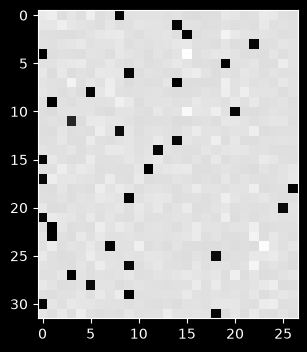

In [18]:
plt.figure(figsize=(4, 4))
plt.imshow(dlogits.detach(), cmap='gray')

In [19]:
hpreact_fast = bngain * (hprebn - hprebn.mean(0, keepdim=True)) / torch.sqrt(hprebn.var(0, keepdim=True, unbiased=True) + 1e-5) + bnbias
print('max diff:', (hpreact_fast - hpreact).abs().max())

max diff: tensor(7.1526e-07, grad_fn=<MaxBackward1>)


In [20]:
dhprebn = bngain*bnvar_inv/n * (n*dhpreact - dhpreact.sum(0) - n/(n-1)*bnraw*(dhpreact*bnraw).sum(0))

cmp('hprebn', dhprebn, hprebn)

hprebn          | exact: False | approximate: False | maxdiff: 0.09224004298448563


In [21]:
dhprebn.shape, bngain.shape, bnvar_inv.shape, dbnraw.shape, dbnraw.sum(0).shape

(torch.Size([32, 64]),
 torch.Size([1, 64]),
 torch.Size([1, 64]),
 torch.Size([32, 64]),
 torch.Size([64]))

In [22]:
n_embd = 10
n_hidden = 200

g = torch.Generator().manual_seed(2147483647)
C  = torch.randn((vocab_size, n_embd),            generator=g)
W1 = torch.randn((n_embd * block_size, n_hidden), generator=g) * (5/3)/((n_embd * block_size)**0.5)
b1 = torch.randn(n_hidden,                        generator=g) * 0.1
W2 = torch.randn((n_hidden, vocab_size),          generator=g) * 0.1
b2 = torch.randn(vocab_size,                      generator=g) * 0.1
bngain = torch.randn((1, n_hidden))*0.1 + 1.0
bnbias = torch.randn((1, n_hidden))*0.1

parameters = [C, W1, b1, W2, b2, bngain, bnbias]
print(sum(p.nelement() for p in parameters))
for p in parameters:
  p.requires_grad = True
max_steps = 200000
batch_size = 32
n = batch_size
lossi = []

with torch.no_grad():

  for i in range(max_steps):

    ix = torch.randint(0, Xtr.shape[0], (batch_size,), generator=g)
    Xb, Yb = Xtr[ix], Ytr[ix]

    emb = C[Xb]
    embcat = emb.view(emb.shape[0], -1)
    hprebn = embcat @ W1 + b1
    bnmean = hprebn.mean(0, keepdim=True)
    bnvar = hprebn.var(0, keepdim=True, unbiased=True)
    bnvar_inv = (bnvar + 1e-5)**-0.5
    bnraw = (hprebn - bnmean) * bnvar_inv
    hpreact = bngain * bnraw + bnbias

    h = torch.tanh(hpreact)
    logits = h @ W2 + b2
    loss = F.cross_entropy(logits, Yb)

    for p in parameters:
      p.grad = None

    dlogits = F.softmax(logits, 1)
    dlogits[range(n), Yb] -= 1
    dlogits /= n
    dh = dlogits @ W2.T
    dW2 = h.T @ dlogits
    db2 = dlogits.sum(0)
    dhpreact = (1.0 - h**2) * dh
    dbngain = (bnraw * dhpreact).sum(0, keepdim=True)
    dbnbias = dhpreact.sum(0, keepdim=True)
    dhprebn = bngain*bnvar_inv/n * (n*dhpreact - dhpreact.sum(0) - n/(n-1)*bnraw*(dhpreact*bnraw).sum(0))
    dembcat = dhprebn @ W1.T
    dW1 = embcat.T @ dhprebn
    db1 = dhprebn.sum(0)
    demb = dembcat.view(emb.shape)
    dC = torch.zeros_like(C)
    for k in range(Xb.shape[0]):
      for j in range(Xb.shape[1]):
        ix = Xb[k,j]
        dC[ix] += demb[k,j]
    grads = [dC, dW1, db1, dW2, db2, dbngain, dbnbias]

    lr = 0.1 if i < 100000 else 0.01
    for p, grad in zip(parameters, grads):
      p.data += -lr * grad

    if i % 10000 == 0:
      print(f'{i:7d}/{max_steps:7d}: {loss.item():.4f}')
    lossi.append(loss.log10().item())

12297
      0/ 200000: 3.7938
  10000/ 200000: 2.1709
  20000/ 200000: 2.3902
  30000/ 200000: 2.4338
  40000/ 200000: 1.9213
  50000/ 200000: 2.3997
  60000/ 200000: 2.4273
  70000/ 200000: 2.0969
  80000/ 200000: 2.3083
  90000/ 200000: 2.1159
 100000/ 200000: 1.9318
 110000/ 200000: 2.3037
 120000/ 200000: 2.0312
 130000/ 200000: 2.4520
 140000/ 200000: 2.2748
 150000/ 200000: 2.2055
 160000/ 200000: 1.8833
 170000/ 200000: 1.7929
 180000/ 200000: 1.9967
 190000/ 200000: 1.9004


In [23]:
with torch.no_grad():
    emb=C[Xtr]
    embcat=emb.view(emb.shape[0],-1)
    hpreact = embcat @ W1 + b1
    bnmean = hpreact.mean(0, keepdim=True)
    bnvar = hpreact.var(0, keepdim=True, unbiased=True)

In [24]:
@torch.no_grad()
def split_loss(split):
  x,y = {
    'train': (Xtr, Ytr),
    'val': (Xdev, Ydev),
    'test': (Xte, Yte),
  }[split]
  emb = C[x]
  embcat = emb.view(emb.shape[0], -1)
  hpreact = embcat @ W1 + b1
  hpreact = bngain * (hpreact - bnmean) * (bnvar + 1e-5)**-0.5 + bnbias
  h = torch.tanh(hpreact)
  logits = h @ W2 + b2
  loss = F.cross_entropy(logits, y)
  print(split, loss.item())

split_loss('train')
split_loss('val')

train 2.0701348781585693
val 2.1079845428466797


In [25]:
g = torch.Generator().manual_seed(2147483647 + 10)

for _ in range(20):

    out = []
    context = [0] * block_size
    while True:

      emb = C[torch.tensor([context])]
      embcat = emb.view(emb.shape[0], -1)
      hpreact = embcat @ W1 + b1
      hpreact = bngain * (hpreact - bnmean) * (bnvar + 1e-5)**-0.5 + bnbias
      h = torch.tanh(hpreact)
      logits = h @ W2 + b2

      probs = F.softmax(logits, dim=1)
      ix = torch.multinomial(probs, num_samples=1, generator=g).item()
      context = context[1:] + [ix]
      out.append(ix)
      if ix == 0:
        break

    print(''.join(itos[i] for i in out))

carmahzael.
harli.
jari.
reet.
khalaysie.
mahnen.
delynn.
jareei.
ner.
kiah.
maiivon.
leigh.
ham.
joce.
quint.
salin.
alvin.
quinterri.
jaryxia.
kaellinsley.
